In [210]:
import importlib
import rasterio
import Utils 
import numpy as np
import Constants
import ConstantObjects
importlib.reload(Utils)
importlib.reload(Constants)
importlib.reload(ConstantObjects)
import inspect
import os
from rasterio.mask import mask


print(f"[Line {inspect.currentframe().f_lineno}] ...  Done with cell. ")

[Line 12] n_cols in ConstantObjects: 21
[Line 14] n_cols: 21, n_rows: 18
[Line 25] n_cols in ConstantObjects: 21
[Line 27] gdf_tree_circles.shape: (378, 1)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783504.354768038 2246750.855941879
-10783527.012462713 2246740.2904853355
-10783520.250570524 2246725.789560743
-10783497.59287585 2246736.3550172867
📍 Center of box: (19.777898, -96.869939)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783477.165534426 2246763.5344897313
-10783499.823229102 2246752.9690331877
-10783479.53755254 2246709.46625941
-10783456.879857862 2246720.0317159537
📍 Center of box: (19.777882, -96.869634)
Constants.n_cols =  21
Constants.n_rows =  18
x0 =  -10783454.50783975
y0 =  2246395.5503548854
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783454.50783975 2246395.5503548854
-10782194.50783975 2246395.5503548854
-10782194.50

In [211]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from IPython.display import display, HTML
display(HTML("<style>.jp-OutputArea {max-height: 200px}</style>"))


rows = []  # collect per-date stats here
#good dates in veracruz are 2024-01-13, 2025-01-12
startDate = "2022-01-03"
#startDate = "2022-05-18"

#startDate = "2025-01-12"

endDate = "2025-08-16"
#endDate = "2022-12-31"


#endDate = "2022-12-31" # temporarily


# Villanueva, VER
#startDate = "2025-01-12"
#endDate = "2025-08-16"
#ethiopia
#startDate = "2021-10-01"
#endDate = "2022-06-30"
#bogus
#startDate = "2021-10-01"
#endDate = "2021-10-01"

dates = Utils.generate_date_range(startDate, endDate,  "%Y-%m-%d", 5)
#datesIncrementDaily = Utils.generate_date_range(startDate, endDate,  "%Y-%m-%d", 1)
print(f"[Line {inspect.currentframe().f_lineno}] ...   ")

precip_df = Utils.daily_precip_openmeteo(Constants.lat0, Constants.lon0, startDate, endDate)
print(f"[Line {inspect.currentframe().f_lineno}] ...   ")

precip_df.head()
print(f"[Line {inspect.currentframe().f_lineno}] ...   ")
                                 
#dates = Utils.generate_date_range("2025-06-16", "2025-06-17",  "%Y-%m-%d", 5)

# jan 12, no cloud directly over farm.
#Feb 11, lots of clouds over farm
ndmi_tile_tif=""
print(f"Cell [Line {inspect.currentframe().f_lineno}] ... dates = ",dates)
        
for date in dates:
    
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... date = ",date)
    gndvi_tile_tif = Utils.make_path_name("s2_derived_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "gndvi","tif")
    ndmi_tile_tif  = Utils.make_path_name("s2_derived_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "ndmi", "tif")
    rgb_tile_tif   = Utils.make_path_name("s2_derived_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "rgb.uint8","tif")

    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... ndmi_tile_tif = ",ndmi_tile_tif)
    gdf_box = ConstantObjects.gdf_box_terreno_casa
    ndmi_terreno_casa_tif = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "ndmi-terreno-casa","tif")
    ndmi_plots_2_3_1A_1B_tif  = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "plots_2_3_1A_1B","tif")
    ndmi_casa_y_vecino_tif  = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "casa_y_vecino","tif")
    #ndmi_milpa_vecino_tif  = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "milpa_vecino","tif")

    b02_terreno_casa_jp2 = Utils.make_path_name("s2_point_series", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "B02","jp2")
    b03_terreno_casa_jp2 = Utils.make_path_name("s2_point_series", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "B03","jp2")
    b04_terreno_casa_jp2 = Utils.make_path_name("s2_point_series", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "B04","jp2")
    if os.path.exists(b02_terreno_casa_jp2) and os.path.exists(b03_terreno_casa_jp2) and os.path.exists(b04_terreno_casa_jp2):
        print(f"[Line {inspect.currentframe().f_lineno}] ... found all three of B02,B03, and B04 .jp2 images. Moving forward. ")
    else:
        print(f"[Line {inspect.currentframe().f_lineno}] ... will have to try the next date, because unable to find files:  ", b02_terreno_casa_jp2 ," , " , b03_terreno_casa_jp2," , " , b04_terreno_casa_jp2  )
        continue #If we do not have all three files for this date we should move on to the next date.
    green_vs_red_blue = np.nan
    rgb_terreno_casa_tif = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "rgb-terreno-casa","tif")

    print(f"[Line {inspect.currentframe().f_lineno}] ... ndmi_terreno_casa_tif = ",ndmi_terreno_casa_tif)

    
    #cloud_terreno_casa = Utils.estimate_cloud_fraction_rgb_over_gdf(rgb_tile_tif, ConstantObjects.gdf_box_terreno_casa,treat_zero_as_nodata=True)
    # add up red intensity
    b2_intensity_terreno_casa = Utils.crop_and_sum_intensity(b02_terreno_casa_jp2, ConstantObjects.gdf_box_terreno_casa, scale_factor=None, clip_to_aoi_bounds=True)
    b3_intensity_terreno_casa = Utils.crop_and_sum_intensity(b03_terreno_casa_jp2, ConstantObjects.gdf_box_terreno_casa, scale_factor=None, clip_to_aoi_bounds=True)
    b4_intensity_terreno_casa = Utils.crop_and_sum_intensity(b04_terreno_casa_jp2, ConstantObjects.gdf_box_terreno_casa, scale_factor=None, clip_to_aoi_bounds=True)
    b2_norm_reflectance_terreno_casa = b2_intensity_terreno_casa["sum"]/b2_intensity_terreno_casa["valid_pixels"]
    b3_norm_reflectance_terreno_casa = b3_intensity_terreno_casa["sum"]/b3_intensity_terreno_casa["valid_pixels"]
    b4_norm_reflectance_terreno_casa = b4_intensity_terreno_casa["sum"]/b4_intensity_terreno_casa["valid_pixels"]
    red_green_blue_average = (b2_norm_reflectance_terreno_casa+b3_norm_reflectance_terreno_casa+b3_norm_reflectance_terreno_casa)/3 
    #SCF continue here..
    cloudy =0
    if (red_green_blue_average) > 1650:  cloudy = 1

    print(f"[Line {inspect.currentframe().f_lineno}] ... calling Utils.crop_ndmi_to_gdf(ndmi_tile_tif, ConstantObjects.gdf_box_terreno_casa, ndmi_terreno_casa_tif) ")
    stats_terreno_casa = {
        "count_valid": 0,
        "mean": float("nan"),
        "median": float("nan"),
    }
    stats_casa_y_vecino = stats_terreno_casa

    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... ")
    if not cloudy: stats_casa_y_vecino  = Utils.crop_ndmi_to_gdf(ndmi_tile_tif, ConstantObjects.gdf_box_casa_y_vecino , ndmi_casa_y_vecino_tif)  

    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... ")

    print("Avg NDMI over AOI plots 4,5:", stats_casa_y_vecino["mean"])
  
    print(f"[Line {inspect.currentframe().f_lineno}] ...  ")
        
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... date  ",date)
    ndmi_plots_4_5_stats       =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_plots_4_5,      ndmi_tile_tif, "ndmi_plots_4_5",       date, cloudy)
    ndmi_plots_2_3_1A_1B_stats =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_plots_2_3_1A_1B,ndmi_tile_tif, "ndmi_plots_2_3_1A_1B", date, cloudy)
    ndmi_milpa_vecino_stats    =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_milpa_vecino,   ndmi_tile_tif, "ndmi_milpa_vecino",    date, cloudy)
    ndmi_terreno_casa_stats    =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_terreno_casa,   ndmi_tile_tif, "ndmi_terreno_casa",    date, cloudy)
    gndvi_plots_4_5_stats      =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_plots_4_5,      gndvi_tile_tif,"gndvi_plots_4_5",      date, cloudy)
    gndvi_plots_2_3_1A_1B_stats=  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_plots_2_3_1A_1B,gndvi_tile_tif,"gndvi_plots_2_3_1A_1B",date, cloudy)
    gndvi_milpa_vecino_stats=  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_milpa_vecino,gndvi_tile_tif,"gndvi_milpa_vecino",date, cloudy)

    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... date  ",date)
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... gndvi_plots_4_5_stats.get(mean,   np.nan) = ",gndvi_plots_4_5_stats.get("mean",   np.nan))
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... gndvi_plots_2_3_1A_1B_stats.get(mean,   np.nan) = ",gndvi_plots_2_3_1A_1B_stats.get("mean",   np.nan))

    rows.append({
        "date": date,
        "ndmi_terreno_casa":      ndmi_terreno_casa_stats.get("mean", np.nan),
        "ndmi_plots_4_5":         ndmi_plots_4_5_stats.get ("mean",   np.nan),
        "gndvi_plots_4_5":        gndvi_plots_4_5_stats.get("mean",   np.nan),
        "gndvi_plots_2_3_1A_1B":  gndvi_plots_2_3_1A_1B_stats.get("mean",   np.nan),
        "gndvi_milpa_vecino":     gndvi_milpa_vecino_stats.get("mean",   np.nan),

        "ndmi_plots_2_3_1A_1B":   ndmi_plots_2_3_1A_1B_stats.get("mean",   np.nan),
        "ndmi_milpa_vecino":      ndmi_milpa_vecino_stats.get("mean",   np.nan),
        "red": b2_norm_reflectance_terreno_casa,
        "green": b3_norm_reflectance_terreno_casa,
        "blue": b4_norm_reflectance_terreno_casa,
        "red_green_blue_average": red_green_blue_average,
        "cloudy" : cloudy *1

    })    
    print(f"[Line {inspect.currentframe().f_lineno}] ... Just appended to rows, an entry with date = ",date)
    print(f"[Cell Line {inspect.currentframe().f_lineno}] ... b2_intensity_terreno_casa[sum]  ",b2_intensity_terreno_casa["sum"])
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... b3_intensity_terreno_casa[sum]  ",b3_intensity_terreno_casa["sum"])
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... b4_intensity_terreno_casa[sum]  ",b4_intensity_terreno_casa["sum"])
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... stats_milpa_vecino.get(mean,   np.nan)  ",stats_milpa_vecino.get("mean",   np.nan))

    #Utils.show_ndmi_moist(ndmi_terreno_casa_tif, scale=12)
    print(f"[Line {inspect.currentframe().f_lineno}] ... calling Utils.crop_ndmi_to_gdf(rgb_tile_tif, ConstantObjects.gdf_box_terreno_casa, rgb_terreno_casa_tif)  ")
 
    #Utils.show_tif_fit(rgb_terreno_casa_tif, scale=12, cmap="gray")
    print(f"[Line {inspect.currentframe().f_lineno}] ... ")

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. Done with cell! ")

[Line 35] ...   
[Line 1300] ...   
[Line 1305] ...   
[Line 1308] ... pd.to_datetime(d[time])   DatetimeIndex(['2022-01-03', '2022-01-04', '2022-01-05', '2022-01-06',
               '2022-01-07', '2022-01-08', '2022-01-09', '2022-01-10',
               '2022-01-11', '2022-01-12',
               ...
               '2025-08-07', '2025-08-08', '2025-08-09', '2025-08-10',
               '2025-08-11', '2025-08-12', '2025-08-13', '2025-08-14',
               '2025-08-15', '2025-08-16'],
              dtype='datetime64[ns]', length=1322, freq=None)
[Line 1309] ... d[precipitation_sum]   [4.0, 0.1, 0.0, 0.1, 3.9, 0.1, 0.8, 5.0, 10.8, 1.2, 1.6, 0.1, 2.5, 9.8, 0.0, 0.0, 0.0, 2.0, 12.0, 5.3, 0.6, 0.0, 0.7, 10.5, 4.6, 9.6, 16.1, 0.3, 0.0, 0.0, 0.0, 0.8, 9.9, 9.4, 0.3, 2.4, 8.9, 12.9, 0.0, 0.1, 0.3, 61.3, 0.2, 0.4, 0.0, 0.0, 0.6, 1.9, 0.5, 0.0, 0.0, 0.0, 0.5, 4.7, 1.5, 3.1, 3.3, 0.5, 0.1, 0.0, 0.0, 0.0, 0.0, 1.0, 0.9, 1.0, 1.5, 0.0, 16.4, 0.6, 0.0, 0.7, 0.8, 2.0, 0.3, 6.2, 5.2, 0.0, 0.3, 4.7, 9.3,

In [212]:
# --- existing: rows -> df (sparse NDMI/Cloud dates)
df = pd.DataFrame(rows)    

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. df = ",df)

df["date"] = pd.to_datetime(df["date"]).dt.normalize()

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. df = ",df)


df = df.sort_values("date")

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

#df = pd.DataFrame(rows)
print(df.columns.tolist())
print(df.head())
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

#Borana University, Ethiopia
#startDate = "2021-10-01"
#endDate = "2022-06-30"

def to_mx_date(col):
    return pd.to_datetime(col, utc=True).dt.tz_convert("America/Mexico_City").dt.normalize()

# --- existing: rows -> df (sparse NDMI/Cloud dates)
df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"]).dt.normalize()
df = df.sort_values("date")

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

# --- existing: daily precip
precip_df = Utils.daily_precip_openmeteo(Constants.lat0, Constants.lon0, startDate, endDate)

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")
p = precip_df.copy()
p["date"] = p["date"].dt.tz_localize(None)
#p["date"] = pd.to_datetime(p["date"]).dt.normalize()
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

temp_df = Utils.daily_temp_openmeteo(Constants.lat0, Constants.lon0, startDate, endDate)
t = temp_df.copy()
t["date"] = pd.to_datetime(t["date"]).dt.tz_localize(None)
#t["date"] = pd.to_datetime(t["date"]).dt.normalize()
p = p.merge(t, on="date", how="left").sort_values("date")
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

#p = p.sort_values("date")

# align daily precip with sparse NDMI, for excel:
out = p.merge(df, on="date", how="left")
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

# save for Excel
out.to_csv("daily_table.csv", index=False)
# or
# out.to_excel("daily_table.xlsx", index=False)
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. Done with cell! ")


[Cell Line 4] .. df =             date  ndmi_terreno_casa  ndmi_plots_4_5  gndvi_plots_4_5  \
0    2022-01-03                NaN             NaN              NaN   
1    2022-01-08           0.042235        0.086148         0.476208   
2    2022-01-13                NaN             NaN              NaN   
3    2022-01-18           0.056051       -0.079957         0.334692   
4    2022-01-23          -0.020437       -0.094524         0.158885   
..          ...                ...             ...              ...   
257  2025-07-26                NaN             NaN              NaN   
258  2025-07-31                NaN             NaN              NaN   
259  2025-08-05                NaN             NaN              NaN   
260  2025-08-10           0.180189        0.168849         0.219972   
261  2025-08-15           0.113826        0.106764         0.347900   

     gndvi_plots_2_3_1A_1B  gndvi_milpa_vecino  ndmi_plots_2_3_1A_1B  \
0                      NaN                 NaN      

[Cell Line 84] .. 
[Cell Line 76] .. my_plot_avg=  0.13304257552538598
[Cell Line 76] .. my_plot_avg=  0.123776416759938
[Cell Line 76] .. my_plot_avg=  0.15063919126987457
[Cell Line 76] .. my_plot_avg=  0.10947078822011297
[Cell Line 89] .. 
[Cell Line 76] .. my_plot_avg=  0.13606437189238413
[Cell Line 76] .. my_plot_avg=  0.13751932978630066
[Cell Line 76] .. my_plot_avg=  0.13925805605120128
[Cell Line 76] .. my_plot_avg=  0.1985131563110785
[Cell Line 94] .. 
[Cell Line 76] .. my_plot_avg=  0.1363008799297469
[Cell Line 76] .. my_plot_avg=  0.1657414473593235
[Cell Line 76] .. my_plot_avg=  0.16622470236486858
[Cell Line 76] .. my_plot_avg=  0.16833149167624387
[Cell Line 101] .. 
[Cell Line 76] .. my_plot_avg=  0.30623344651290346
[Cell Line 76] .. my_plot_avg=  0.34063862902777536
[Cell Line 76] .. my_plot_avg=  0.32646844949987197
[Cell Line 76] .. my_plot_avg=  0.34840457141399384
[Cell Line 106] .. 
[Cell Line 76] .. my_plot_avg=  0.31672622902052744
[Cell Line 76] .. my_plo

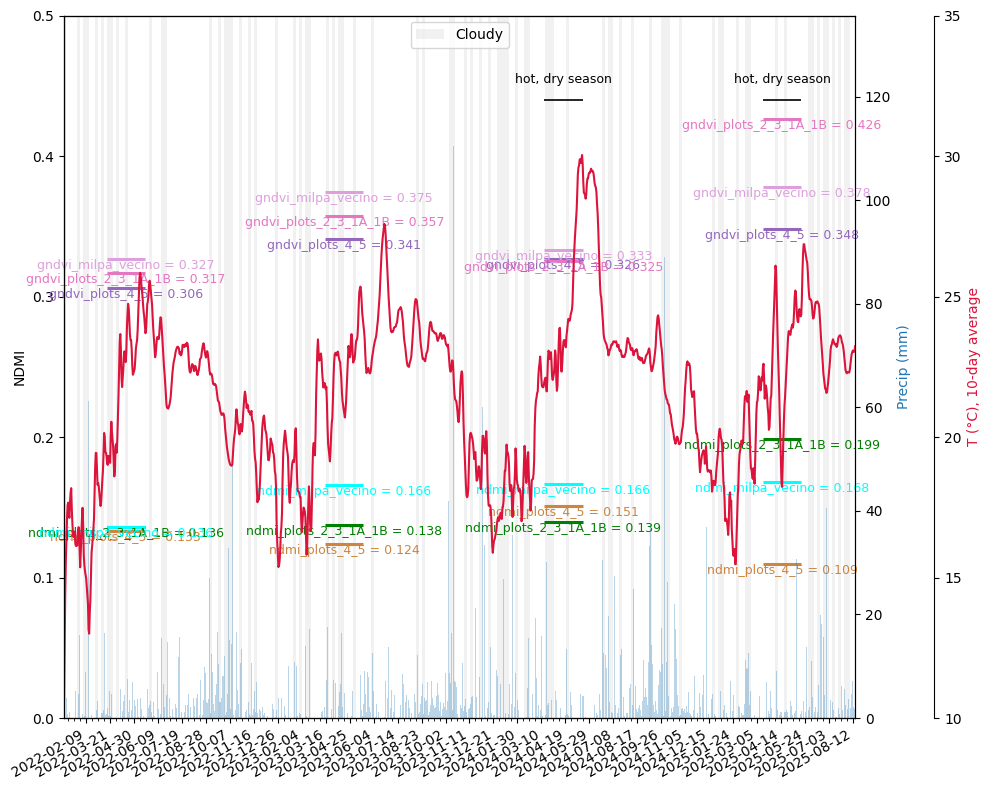

In [214]:

from IPython.display import display, HTML

display(HTML("<style>.jp-OutputArea {max-height: 20000px;min_height: 20000px;}</style>"))

# --- colors for consistency
precip_color = "tab:blue"
temperature_color   = "crimson"

# --- plot: NDMI (left), cloud (right), DAILY precip on a second right axis
fig, ax = plt.subplots(figsize=(10, 8))
# NDMI lines (sparse dates)
ax.set_ylim(-.0, .5)
#ax.plot(df["date"], df["gndvi_plots_4_5"],      marker="o", label="GNDVI plots 4,5",       color = "tab:purple")
#ax.plot(df["date"], df["gndvi_plots_2_3_1A_1B"],marker="o", label="GNDVI plots 2,3,1A,1B", color = "tab:pink")
#ax.plot(df["date"], df["gndvi_milpa_vecino"],marker="o", label="GNDVI milpa vecino", color = "plum")

##ax.plot(df["date"], df["ndmi_terreno_casa"],marker="o", label="NDMI terreno casa", color = "forestgreen")
#ax.plot(df["date"], df["ndmi_plots_4_5"],      marker=".", label="NDMI plots 4,5",      color = "peru")
#ax.plot(df["date"], df["ndmi_plots_2_3_1A_1B"],marker=".", label="NDMI plots 2,3,1A,1B",color = "gold")
#ax.plot(df["date"], df["ndmi_milpa_vecino"],   marker=".", label="NDMI milpa vecino",   color = "cyan")

ax.bar(df["date"], df["cloudy"].fillna(0)*.6,color="lightgrey",
        width=pd.Timedelta("5D"), alpha=0.3, label="Cloudy")

ax.set_ylabel("NDMI")
ax.legend(loc="upper center")

#ax3.spines["right"].set_position(("axes", 1.08))   # offset so both right axes are visible
ax.set_frame_on(True); ax.patch.set_visible(False)

ax2 = ax.twinx()
ax2.set_ylabel("Precip (mm)",color=precip_color)
# Precip (second right axis; ALL daily bars)
ax2.bar(p["date"], p["precip_mm"].fillna(0),
        width=pd.Timedelta("0.85D"), alpha=0.3, label="Precip (mm)",color=precip_color)

# Max temperature (third axis)
ax3 = ax.twinx()
ax3.set_ylim(10, 35)
ax3.spines["right"].set_position(("axes", 1.10))  # shift outward
p["tave_10d"] = p["tavg"].rolling(window=10, min_periods=1).mean()
ax3.plot(p["date"], p["tave_10d"],color=temperature_color, lw=1.5, label="T 10-day back-average (°C)") # takes min,max, avg
ax3.set_ylabel("T (°C), 10-day average",color=temperature_color)
ax3.grid(False)

# horizontal line
s2025 = pd.to_datetime("2025-03-01")
#e2025 = pd.to_datetime("2025-05-31")
s2025 = pd.to_datetime("2025-03-15") # hot season, per https://weatherspark.com/y/11299/Average-Weather-in-Veracruz-Mexico-Year-Round
e2025 = pd.to_datetime("2025-05-18")
m2025   = s2025 + (e2025 - s2025)/2
# draw a line across the interval at 90% height of NDMI axis
ax.hlines(y=0.44, xmin=s2025, xmax=e2025, color="black", lw=1.2)
# put label slightly above the line
ax.text(m2025, 0.45, "hot, dry season", ha="center", va="bottom", fontsize=9)


# --- NDMI average line for 2025-03-01 .. 2025-05-31 ---
s2024 = s2025 - pd.DateOffset(years=1)
e2024 = e2025 - pd.DateOffset(years=1)
s2023 = s2025 - pd.DateOffset(years=2)
e2023 = e2025 - pd.DateOffset(years=2)
s2022 = s2025 - pd.DateOffset(years=3)
e2022 = e2025 - pd.DateOffset(years=3)

ndmi_avg_2024 = df.loc[(df["date"] >= s2024) & (df["date"] <= e2024), "ndmi_terreno_casa"].mean()
ndmi_avg_2023 = df.loc[(df["date"] >= s2023) & (df["date"] <= e2023), "ndmi_terreno_casa"].mean()
ndmi_avg_2022 = df.loc[(df["date"] >= s2022) & (df["date"] <= e2022), "ndmi_terreno_casa"].mean()
ndmi_plots_2_3_1A_1B_avg_2024 = df.loc[(df["date"] >= s2024) & (df["date"] <= e2024), "ndmi_plots_2_3_1A_1B"].mean()


## do plots 4,5 for 2024 here
#start date of season, end date of season, dataframe containing daily ndmi, matplotlib axis
def add_season_avg_ndmi_to_axis(my_start_date,my_end_date,my_df,plot_name,my_ax,my_color):
    my_plot_avg = my_df.loc[(my_df["date"] >= my_start_date) & (my_df["date"] <= my_end_date), plot_name].mean()
    print(f"[Cell Line {inspect.currentframe().f_lineno}] .. my_plot_avg= ",my_plot_avg)
    if pd.notna(my_plot_avg):
        ax.hlines(y=my_plot_avg, xmin=my_start_date, xmax=my_end_date,
              colors=my_color, linewidth=2.2)
        ax.text(my_start_date + (my_end_date - my_start_date)/2, my_plot_avg,
            f"{plot_name} = {my_plot_avg:.3f}", ha="center", va="top",
            fontsize=9, color=my_color)
        
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")
add_season_avg_ndmi_to_axis(s2022,e2022,df,"ndmi_plots_4_5",ax,"peru")
add_season_avg_ndmi_to_axis(s2023,e2023,df,"ndmi_plots_4_5",ax,"peru")
add_season_avg_ndmi_to_axis(s2024,e2024,df,"ndmi_plots_4_5",ax,"peru")
add_season_avg_ndmi_to_axis(s2025,e2025,df,"ndmi_plots_4_5",ax,"peru")
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")
add_season_avg_ndmi_to_axis(s2022,e2022,df,"ndmi_plots_2_3_1A_1B",ax,"green")
add_season_avg_ndmi_to_axis(s2023,e2023,df,"ndmi_plots_2_3_1A_1B",ax,"green")
add_season_avg_ndmi_to_axis(s2024,e2024,df,"ndmi_plots_2_3_1A_1B",ax,"green")
add_season_avg_ndmi_to_axis(s2025,e2025,df,"ndmi_plots_2_3_1A_1B",ax,"green")
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")
add_season_avg_ndmi_to_axis(s2022,e2022,df,"ndmi_milpa_vecino",ax,"cyan")
add_season_avg_ndmi_to_axis(s2023,e2023,df,"ndmi_milpa_vecino",ax,"cyan")
add_season_avg_ndmi_to_axis(s2024,e2024,df,"ndmi_milpa_vecino",ax,"cyan")
add_season_avg_ndmi_to_axis(s2025,e2025,df,"ndmi_milpa_vecino",ax,"cyan")


print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")
add_season_avg_ndmi_to_axis(s2022,e2022,df,"gndvi_plots_4_5",ax,"tab:purple")
add_season_avg_ndmi_to_axis(s2023,e2023,df,"gndvi_plots_4_5",ax,"tab:purple")
add_season_avg_ndmi_to_axis(s2024,e2024,df,"gndvi_plots_4_5",ax,"tab:purple")
add_season_avg_ndmi_to_axis(s2025,e2025,df,"gndvi_plots_4_5",ax,"tab:purple")
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")
add_season_avg_ndmi_to_axis(s2022,e2022,df,"gndvi_plots_2_3_1A_1B",ax,"tab:pink")
add_season_avg_ndmi_to_axis(s2023,e2023,df,"gndvi_plots_2_3_1A_1B",ax,"tab:pink")
add_season_avg_ndmi_to_axis(s2024,e2024,df,"gndvi_plots_2_3_1A_1B",ax,"tab:pink")
add_season_avg_ndmi_to_axis(s2025,e2025,df,"gndvi_plots_2_3_1A_1B",ax,"tab:pink")
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")
add_season_avg_ndmi_to_axis(s2022,e2022,df,"gndvi_milpa_vecino",ax,"plum")
add_season_avg_ndmi_to_axis(s2023,e2023,df,"gndvi_milpa_vecino",ax,"plum")
add_season_avg_ndmi_to_axis(s2024,e2024,df,"gndvi_milpa_vecino",ax,"plum")
add_season_avg_ndmi_to_axis(s2025,e2025,df,"gndvi_milpa_vecino",ax,"plum")

  
# horizontal line
#start = pd.to_datetime("2024-03-01")
#end   = pd.to_datetime("2024-05-31")
m2024   = s2024 + (e2024 - s2024)/2
# draw a line across the interval at 90% height of NDMI axis
ax.hlines(y=0.44, xmin=s2024, xmax=e2024, color="black", lw=1.2)
# put label slightly above the line
ax.text(m2024, 0.45, "hot, dry season", ha="center", va="bottom", fontsize=9)

# Align x-limits to cover full  range too
xmin = min(df["date"].min(), p["date"].min())
xmax = max(df["date"].max(), p["date"].max())
ax.set_xlim(xmin, xmax)
ax.xaxis.set_minor_locator(mdates.DayLocator(interval=10))   # tick every 5 days
ax.xaxis.set_major_locator(mdates.DayLocator(interval=40)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

fig.autofmt_xdate()
fig.tight_layout()
plt.show()
fig.savefig("ndmi_temp_precipitation_plot.png", dpi=300, bbox_inches="tight")